# GradCAM - Gradient Class Activation Map

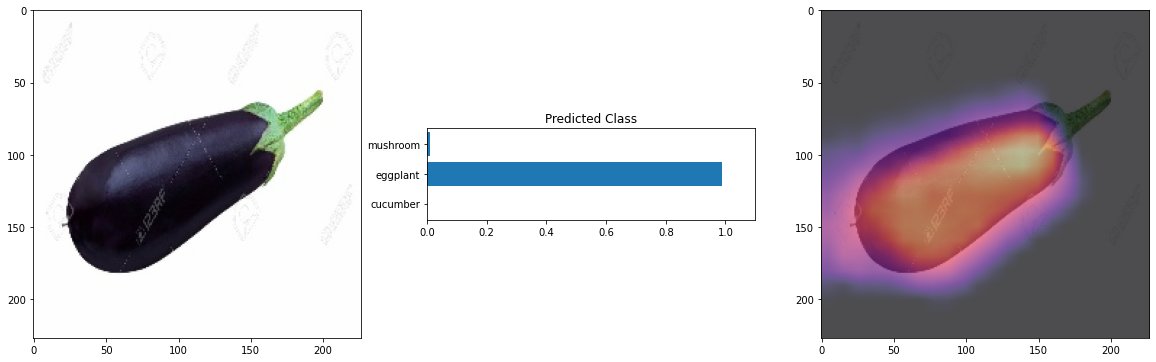

In [1]:
!git clone https://github.com/parth1620/GradCAM-Dataset.git
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install --upgrade opencv-contrib-python

Cloning into 'GradCAM-Dataset'...
remote: Enumerating objects: 193, done.
remote: Counting objects: 100% (193/193), done.
remote: Compressing objects: 100% (193/193), done.
remote: Total 193 (delta 0), reused 193 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (193/193), 2.59 MiB | 24.76 MiB/s, done.
  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-b0t40_iv
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-b0t40_iv
  Resolved https://github.com/albumentations-team/albumentations to commit 66212d77a44927a29d6a0e81621d3c27afbd929c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Attempting uninstall: albucore
    Found existing installation: albucore 0.0.24
    Uninstalling albucore-0.0.24:
      Successfully uninstalled albucore-0.0.24
ERROR: pip's dependency resolver does not 

# Imports

In [2]:
import sys
sys.path.append('/content/GradCAM-Dataset')

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
from torch import nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms as T
import torchvision.models as models

from tqdm import tqdm
import albumentations as A
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import utils

# Configurations

In [5]:
CSV_FILE = '/content/GradCAM-Dataset/train.csv'
DATA_DIR = '/content/GradCAM-Dataset/'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 16
LR = 0.001
EPOCHS = 20

In [6]:
data = pd.read_csv(CSV_FILE)
data.head()

,img_path,label
0,train_images/mushroom_51.jpg,2
1,train_images/eggplant_37.jpg,1
2,train_images/mushroom_20.jpg,2
3,train_images/eggplant_51.jpg,1
4,train_images/eggplant_26.jpg,1


In [7]:
data.label.value_counts()

,count
label,
0,63
1,62
2,61


In [8]:
id2label = {0: 'cucumber', 1: 'eggplant', 2: 'mushroom'}
label2id = {v: k for k, v in id2label.items()}
id2label, label2id

({0: 'cucumber', 1: 'eggplant', 2: 'mushroom'},
 {'cucumber': 0, 'eggplant': 1, 'mushroom': 2})

In [9]:
train_df, valid_df = train_test_split(data, test_size=0.2, random_state=42, stratify=data['label'])

In [10]:
train_df

,img_path,label
101,train_images/cucumber_25.jpg,0
10,train_images/eggplant_9.jpg,1
172,train_images/mushroom_26.jpg,2
177,train_images/eggplant_10.jpg,1
80,train_images/eggplant_31.jpg,1
...,...,...
24,train_images/mushroom_38.jpg,2
49,train_images/mushroom_41.jpg,2
8,train_images/cucumber_62.jpg,0
28,train_images/mushroom_6.jpg,2


In [11]:
valid_df

,img_path,label
123,train_images/eggplant_32.jpg,1
148,train_images/cucumber_7.jpg,0
89,train_images/cucumber_49.jpg,0
87,train_images/eggplant_36.jpg,1
54,train_images/cucumber_56.jpg,0
132,train_images/mushroom_40.jpg,2
81,train_images/mushroom_43.jpg,2
66,train_images/cucumber_57.jpg,0
85,train_images/eggplant_2.jpg,1
100,train_images/eggplant_13.jpg,1


In [12]:
len(train_df), len(valid_df)

(148, 38)

# Augmentations

In [13]:
train_augs = A.Compose([
    A.Resize(224, 224),
    A.Rotate(),
    A.HorizontalFlip(0.5),
    A.VerticalFlip(0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_augs

Compose([
  Resize(p=1.0, area_for_downscale=None, height=224, interpolation=1, mask_interpolation=0, width=224),
  Rotate(p=0.5, border_mode=0, crop_border=False, fill=0.0, fill_mask=0.0, interpolation=1, limit=(-90.0, 90.0), mask_interpolation=0, rotate_method='largest_box'),
  HorizontalFlip(p=0.5),
  VerticalFlip(p=0.5),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0.229, 0.224, 0.225)),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)

In [14]:
valid_augs = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
valid_augs

Compose([
  Resize(p=1.0, area_for_downscale=None, height=224, interpolation=1, mask_interpolation=0, width=224),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0.229, 0.224, 0.225)),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)

# Load Image Dataset

In [15]:
trainset = utils.ImageDataset(train_df, augs=train_augs, data_dir=DATA_DIR)
validset = utils.ImageDataset(valid_df, augs=valid_augs, data_dir=DATA_DIR)

In [16]:
image, label = trainset[0]
image.shape, label.shape

(torch.Size([3, 224, 224]), ())

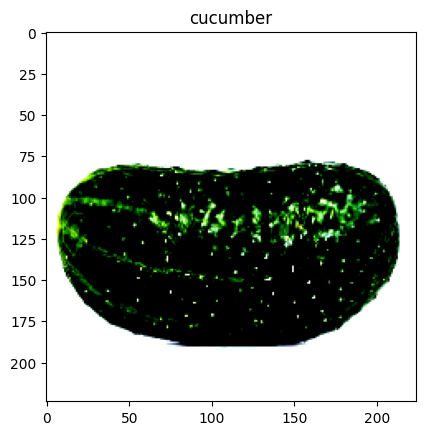

In [17]:
plt.imshow(image.permute(1,2,0))
plt.title(id2label[label])
plt.show()

In [18]:
print(f"No. of examples in the trainset is {len(trainset)}")
print(f"No. of examples in the validset is {len(validset)}")

No. of examples in the trainset is 148
No. of examples in the validset is 38


# Load Dataset into Batches

In [19]:
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
validloader = DataLoader(validset, batch_size=BATCH_SIZE, shuffle=False)

In [20]:
print(f"No. of batches in trainloader : {len(trainloader)}")
print(f"No. of batches in validloader : {len(validloader)}")

No. of batches in trainloader : 10
No. of batches in validloader : 3


In [21]:
images, labels = next(iter(trainloader))

print(f"One batch image shape : {images.shape}")
print(f"One batch label shape : {labels.shape}")

One batch image shape : torch.Size([16, 3, 224, 224])
One batch label shape : torch.Size([16])


# Create Model

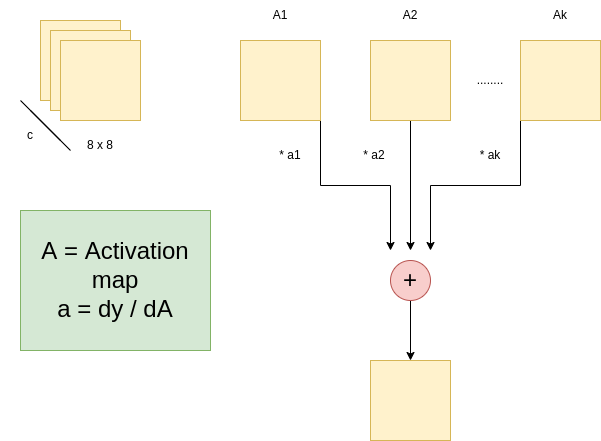

In [22]:
model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 203MB/s]


In [23]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [24]:
#model.fc = nn.Sequential(nn.Flatten(),
#                         nn.Linear(512, 128, bias=False),
#                         nn.BatchNorm1d(128),
#                         nn.ReLU(inplace=True),
#                         nn.Dropout(0.4),
#                         nn.Linear(128, 3)
#                         )

In [25]:
# Get all child modules and convert to a list
layers = list(model.children())

# Reconstruct the model using all layers except the last one (the 'fc' layer)
model = nn.Sequential(*layers[:-2])

# Add a Flatten layer to prepare for a new classification head
#feature_extractor.add_module('flatten', nn.Flatten())

# Print the new model structure
print(model)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [26]:
inp = torch.ones(2, 3, 224, 224)
out = model(inp)
out.shape

torch.Size([2, 512, 7, 7])

In [27]:
class ImageModel(nn.Module):
    def __init__(self, model):

        super().__init__()


        self.model = model #This will output 512x7x7
        self.aggregate = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = nn.Sequential(nn.Flatten(),
                                        nn.Linear(512, 128, bias=False),
                                        nn.BatchNorm1d(128),
                                        nn.ReLU(inplace=True),
                                        nn.Dropout(0.4),
                                        nn.Linear(128, 3)
                                       )
        self.gradient = None

    def activations_hook(self, grad):
      self.gradient = grad

    def get_activation_gradients(self): #a1, a2...ak(weights) A1*a1 like that
      return self.gradient

    def get_activation(self, x):  #activation Maps 512X7X7  A1, A2..Ak
      return self.model(x)

    def forward(self, x):
        x = self.model(x) #512x7x7 activation maps A1, A2..Ak

        h = x.register_hook(self.activations_hook)
        x = self.aggregate(x)

        x = self.classifier(x)
        return x

In [28]:
model_gc = ImageModel(model)
model_gc.to(DEVICE)

ImageModel(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [29]:
!pip install torchinfo
from torchinfo import summary

In [31]:
inp = torch.ones(2, 3, 224, 224).to(DEVICE)
out = model_gc(inp)
out.shape

torch.Size([2, 3])

# Create Train and Eval function

In [37]:
def train_fn(dataloader, model, optimizer, criterion):
  model.train()
  total_loss = 0.0
  for images, labels in tqdm(dataloader):
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    optimizer.zero_grad()
    logits = model(images)
    loss = criterion(logits, labels)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
  return total_loss/len(dataloader)




In [38]:
def eval_fn(dataloader, model, criterion):
  model.eval()
  total_loss = 0.0
  for images, labels in tqdm(dataloader):
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)

    logits = model(images)
    loss = criterion(logits, labels)
    total_loss += loss.item()
  return total_loss/len(dataloader)

# Training Loop

In [39]:
LR, EPOCHS

(0.001, 20)

In [40]:
optimizer = torch.optim.Adam(model_gc.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

In [41]:
best_valid_loss = np.inf

for i in range(EPOCHS):
  train_loss = train_fn(trainloader, model_gc, optimizer, criterion)
  valid_loss = eval_fn(validloader, model_gc, criterion)

  if valid_loss<best_valid_loss:
    torch.save(model.state_dict(), 'best_weights.pt')
    best_valid_loss = valid_loss
    print("SAVED_WEIGHTS_SUCCESS")

  print(f'EPOCH: {i+1} TRAIN_LOSS: {train_loss} VALID_LOSS: {valid_loss}')

100%|██████████| 3/3 [00:00<00:00, 31.57it/s]


SAVED_WEIGHTS_SUCCESS
EPOCH: 1 TRAIN_LOSS: 0.3240375518798828 VALID_LOSS: 0.2084780385096868


100%|██████████| 3/3 [00:00<00:00, 31.62it/s]


EPOCH: 2 TRAIN_LOSS: 0.36820296496152877 VALID_LOSS: 5.708181778589885


100%|██████████| 3/3 [00:00<00:00, 33.50it/s]


...

EPOCH: 18 TRAIN_LOSS: 0.4928961295634508 VALID_LOSS: 0.0914152388771375


100%|██████████| 3/3 [00:00<00:00, 25.94it/s]


EPOCH: 19 TRAIN_LOSS: 0.10734580233693122 VALID_LOSS: 0.054210388412078224


100%|██████████| 3/3 [00:00<00:00, 34.44it/s]

EPOCH: 20 TRAIN_LOSS: 0.3165999561548233 VALID_LOSS: 0.11785562212268512


In [42]:
best_valid_loss

0.04528450717528661

# Get GradCAM

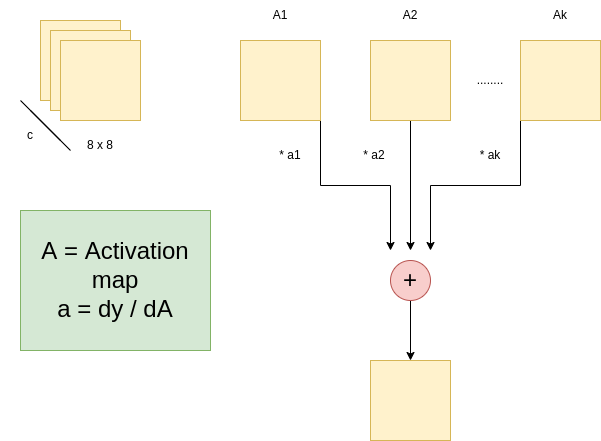

In [162]:
def get_gradcam(model, image, label, size):
  label.backward()
  gradients = model.get_activation_gradients() ##Gives grdients according to activation hook regd in forward function
  pooled_gradients = torch.mean(gradients, dim=[0,2,3]) ##a1, a2 ..ak
  activations = model.get_activation(image).detach()  ##A1, A2..Ak

  for i in range(activations.shape[1]):
    activations[:, i, :, :] *= pooled_gradients[i]

  heatmap = torch.mean(activations, dim=1).squeeze().cpu()
  heatmap = nn.ReLU()(heatmap)
  heatmap /= torch.max(heatmap)
  heatmap = cv2.resize(heatmap.numpy(), (224, 224))
  return heatmap

In [163]:
image, label = validset[5]
image.shape, label.shape, label

(torch.Size([3, 224, 224]), (), np.int64(2))

In [164]:
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]
mean, std

([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

In [165]:
denorm_image = image.permute(1, 2, 0) * np.array(std) + np.array(mean)
image = image.unsqueeze(0).to(DEVICE)
pred = model_gc(image)

/tmp/ipython-input-2498349452.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denorm_image = image.permute(1, 2, 0) * np.array(std) + np.array(mean)


In [166]:
pred, pred.shape

(tensor([[-1.6260, -1.4469,  2.5025]], device='cuda:0',
        grad_fn=<AddmmBackward0>),
 torch.Size([1, 3]))

In [167]:
pred_max = torch.argmax(pred, dim = -1)
pred_max

tensor([2], device='cuda:0')

In [168]:
label

np.int64(2)

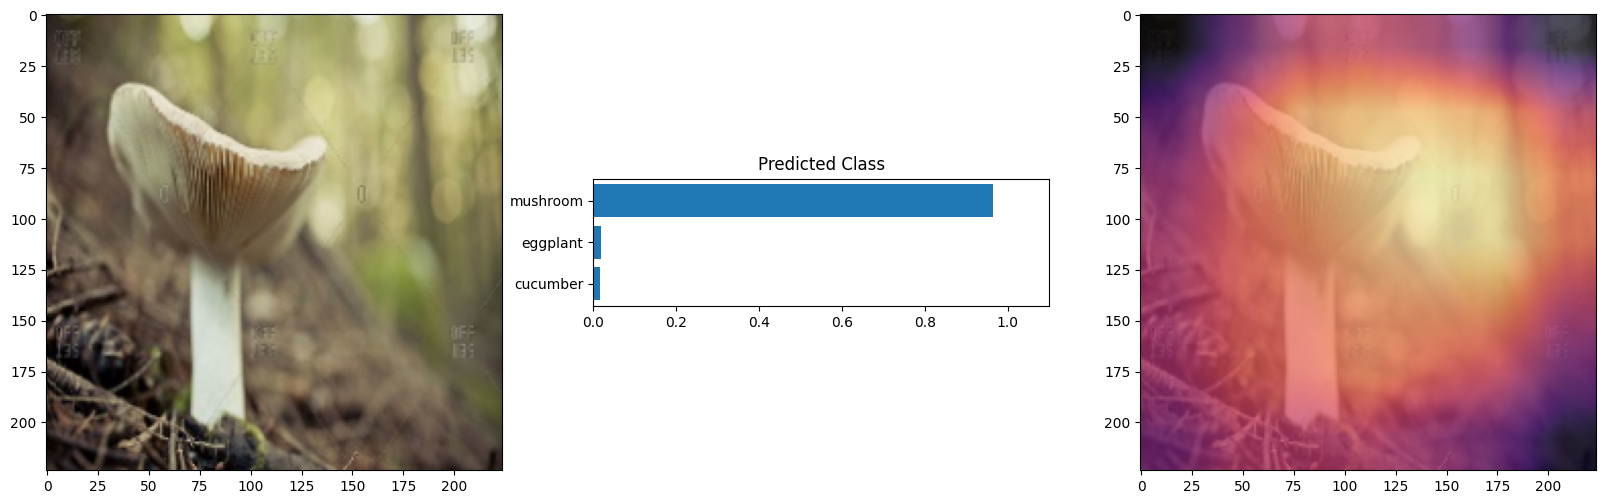

In [169]:
heatmap = get_gradcam(model_gc, image, pred[0][pred_max], size=224)
utils.plot_heatmap(denorm_image, pred, heatmap)

'cucumber'